In [1]:
%load_ext autoreload
%autoreload 2

# Model differencing

`lensboy` has tools to compare two different camera intrinsics.

This can be useful to, for example
* Cross-validate your calibration
* Check whether your camera calibrtion has changed
* Compare two cameras of the same type to see how much the intrinsics differ

In this notebook, we'll explore how to do this with `lensboy`.


In [2]:
from pathlib import Path
import imageio.v3 as iio
import mediapy
import cv2

import lensboy as lb
import lensboy.analysis as lba

## Load dataset

""

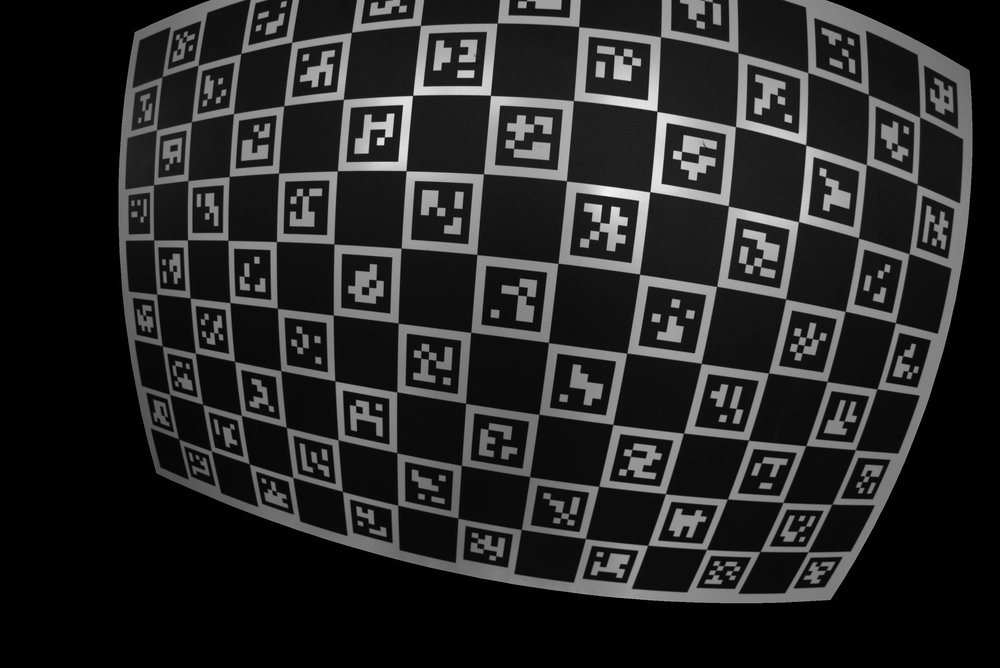

In [3]:
img_directory = Path("../data/images/wide_angle_charuco_private")
img_paths = sorted(img_directory.glob("*.png"))
imgs = [iio.imread(pth) for pth in img_paths]

# if you're running the notebook yourself, you can use this for synthetic images
# from lensboy.demo import make_synthetic_images
# imgs = make_synthetic_images()

mediapy.show_image(imgs[0], width=1000)

Extract charuco detections from the images.

In [4]:
board = cv2.aruco.CharucoBoard(
    (14, 9), 40, 30, cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_5X5_100)
)
target_points, frames, image_indices = lb.extract_frames_from_charuco(board, imgs)
used_imgs = [imgs[i] for i in image_indices]

image_height, image_width = used_imgs[0].shape[:2]

Detecting charuco: 101/101 (100.0%)
Detected charuco in 101/101 images


We'll split the dataset in two

In [5]:
frames_a = frames[0::2]
frames_b = frames[1::2]

print(f"{len(frames_a)=}, {len(frames_b)=}")


len(frames_a)=51, len(frames_b)=50


Let's make sure each set has decent coverage:

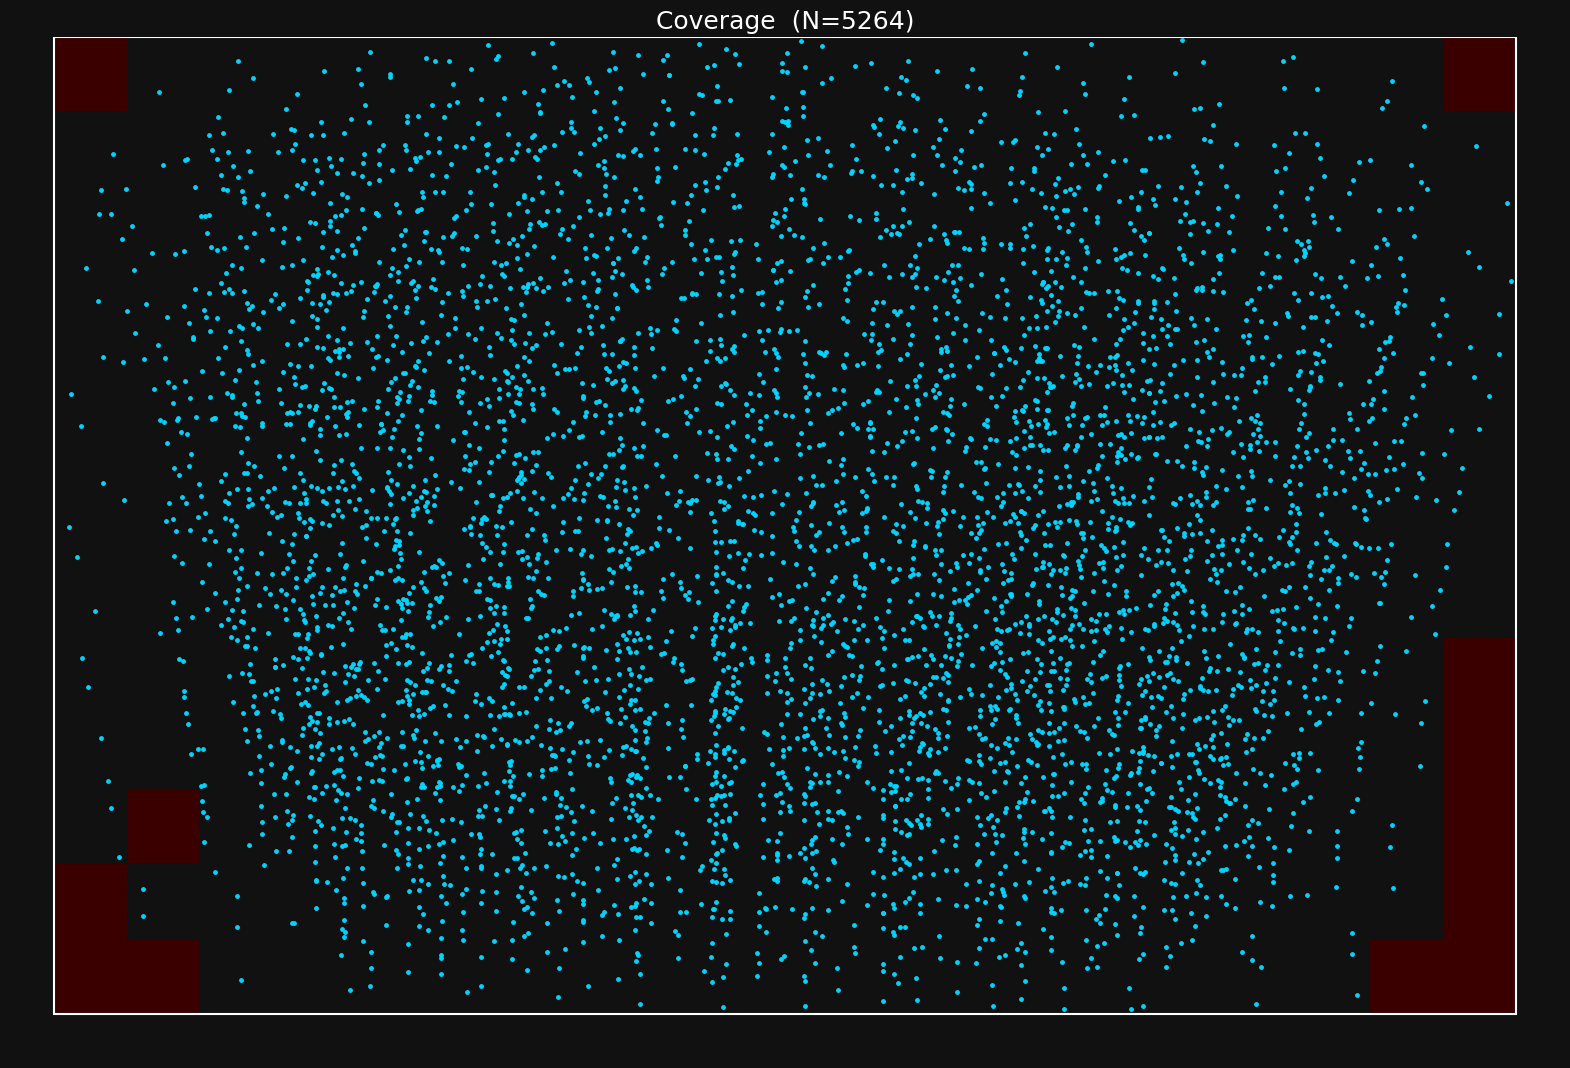

In [6]:
lba.plot_detection_coverage(
    frames_a, 
    image_width=image_width, 
    image_height=image_height
)

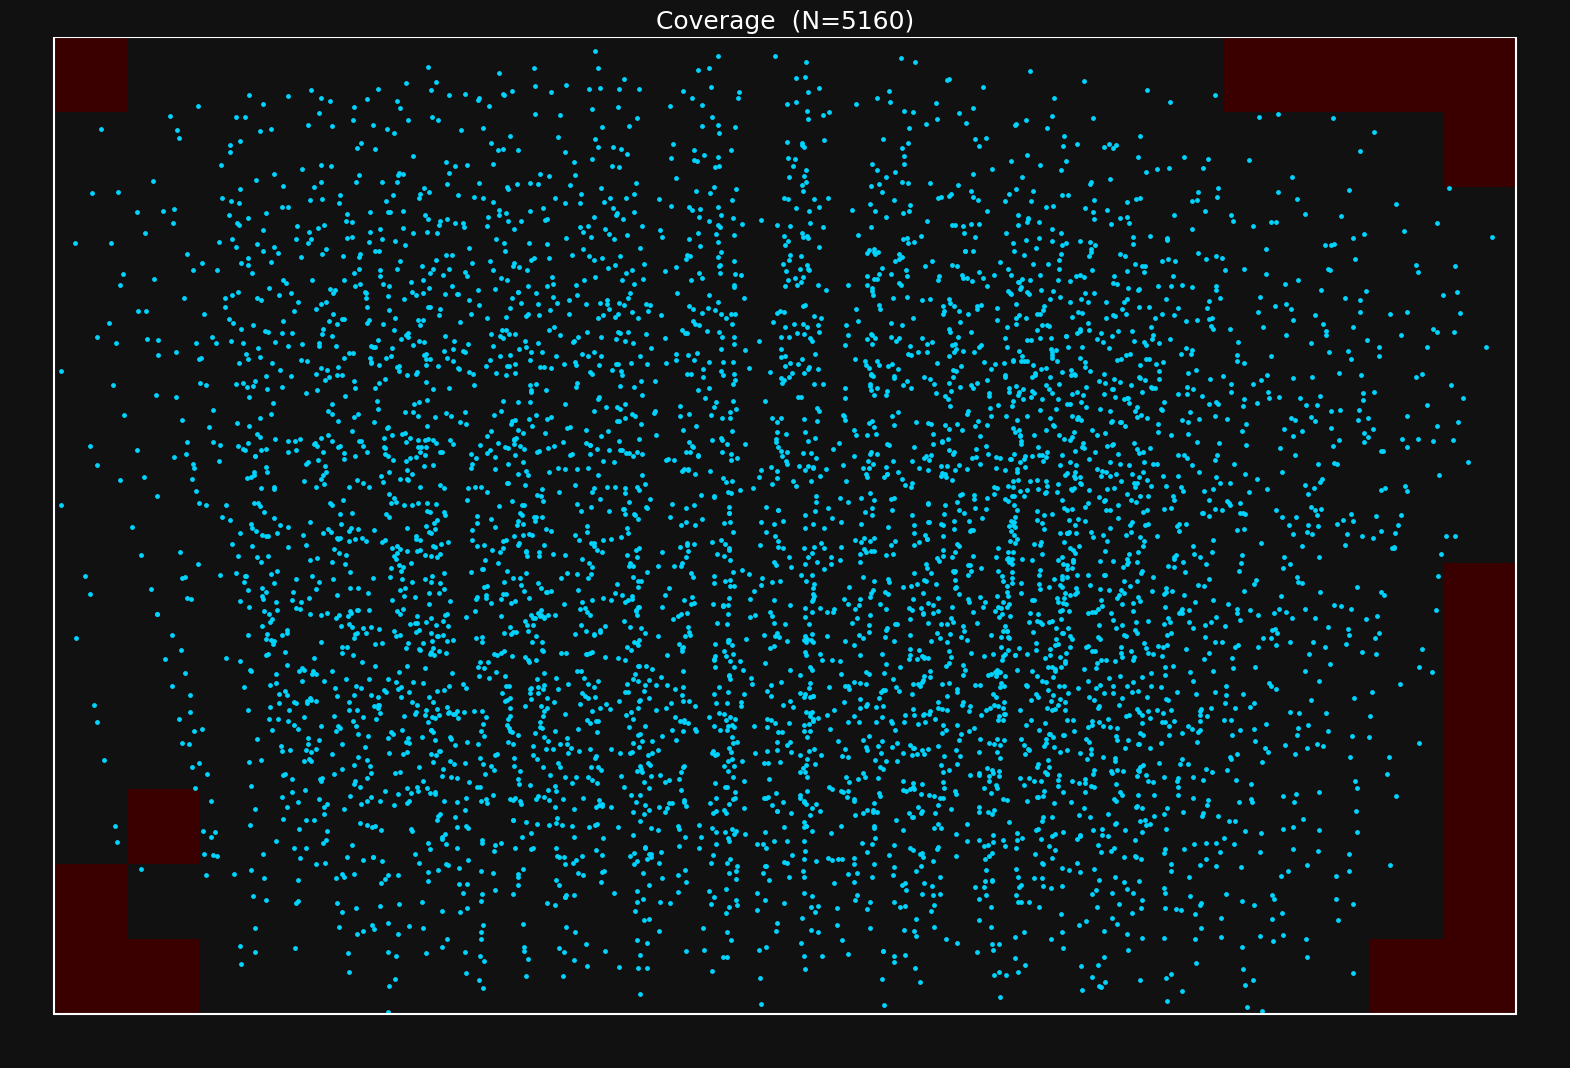

In [7]:
lba.plot_detection_coverage(
    frames_b, 
    image_width=image_width, 
    image_height=image_height
)

Looks like we have decent coverage on both sets, so we can reasonably expect to get good models from each frame set.

Let's fit an opencv model on each frame set:

In [8]:

config = lb.OpenCVConfig(
    image_height=image_height,
    image_width=image_width,
    included_distortion_coefficients=lb.OpenCVConfig.FULL_14,
)

result_a = lb.calibrate_camera(
    target_points, 
    frames_a, 
    camera_model_config=config
)

result_b = lb.calibrate_camera(
    target_points, 
    frames_b, 
    camera_model_config=config
)

opencv_model_a = result_a.camera_model
opencv_model_b = result_b.camera_model

print(f"Model A sigma: {result_a.residual_sigma_map():.3f} px")
print(f"Model B sigma: {result_b.residual_sigma_map():.3f} px")

Computing initial poses with PnP...
Auto-estimated initial focal length: 1500.9 px
PnP solved 51/51 frames
Running full optimization...
Ran optimizer in 0.35s
Outlier filtering: 39/5264 (0.7%) outliers - going again...
Running full optimization...
Ran optimizer in 0.10s
Outlier filtering: 49/5264 (0.9%) outliers - going again...
Running full optimization...
Ran optimizer in 0.07s
Target warp max deflection: 0.4622 (target units)
Residuals (inliers): mean=0.141px, worst=0.607px
Computing initial poses with PnP...
Auto-estimated initial focal length: 1677.1 px
PnP solved 50/50 frames
Running full optimization...
Ran optimizer in 0.33s
Outlier filtering: 44/5160 (0.9%) outliers - going again...
Running full optimization...
Ran optimizer in 0.18s
Outlier filtering: 56/5160 (1.1%) outliers - going again...
Running full optimization...
Ran optimizer in 0.07s
Target warp max deflection: 0.4753 (target units)
Residuals (inliers): mean=0.135px, worst=0.524px
Model A sigma: 0.107 px
Model B sigm

Now we're ready to compare the models.

Camera intrinsics have an implied reference frame inside the physical camera. The plot tries to fit this transformation in an optimization problem, and uses it when comparing the intrinsics. See this [mrcal documentation](https://mrcal.secretsauce.net/differencing.html) for more details.

The plot shows how the same points project into each camera, with the cameras stationed relative to each other according to the fitted pose difference:

Implied rotation: x=-0.0019 y=-0.0193 z=-0.0004 deg
Implied translation: [-3.52212106e-07  1.74686182e-08  1.74686182e-08]


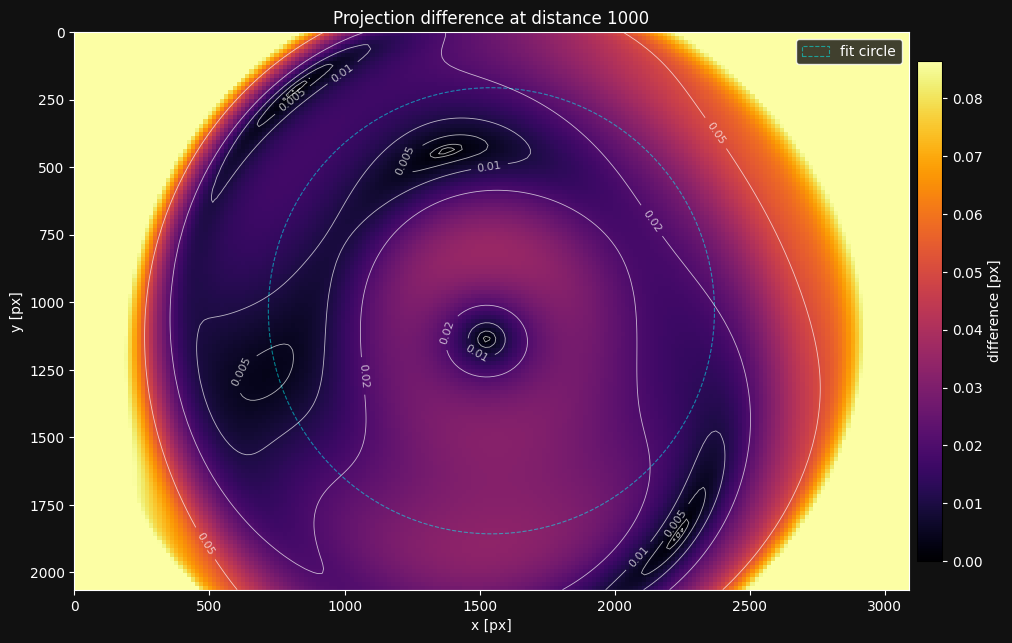

In [9]:
lba.plot_projection_diff(opencv_model_a, opencv_model_b, distance=1000)

Looks like our models align pretty well - we can say that our calibrations are pretty consistent when using the opencv model.
A possible reason is that the opencv models are so lean, they do not have the flexibility to make two models over/underfit in different ways on similar data.

## Spline models
Let's try the same with spline models. We'll look at increasing grid densities in a loop:

Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1500.9 px
PnP solved 51/51 frames
Running full optimization...
Ran optimizer in 0.30s
Residuals (inliers): mean=0.235px, worst=5.167px
OpenCV seed model ready in 0.7s
Computed FOV from OpenCV model: 141.9° x 124.2°
Calculating matching spline model...
Matching spline model ready in 0.2s
Running full optimization...
Performed full optimization in 2.99s
Outlier filtering: 5/5264 (0.1%) outliers - going again...
Running full optimization...
Performed full optimization in 3.08s
Target warp max deflection: 0.4047 (target units)
Residuals (inliers): mean=0.520px, worst=1.651px
Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1677.1 px
PnP solved 50/50 frames
Running full optimization...
Ran optimizer in 0.30s
Residuals (inliers): mean=0.233px, worst=3.928px
OpenCV seed model ready in 0.8s
Computed FOV from OpenCV model: 141.8° x 12

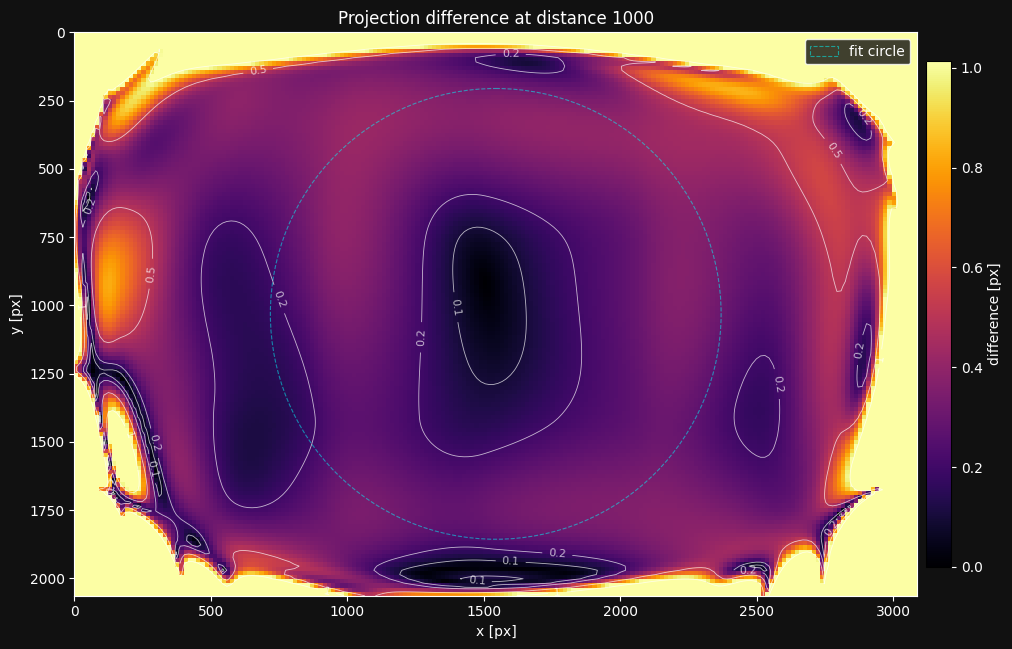

Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1500.9 px
PnP solved 51/51 frames
Running full optimization...
Ran optimizer in 0.32s
Residuals (inliers): mean=0.235px, worst=5.167px
OpenCV seed model ready in 0.8s
Computed FOV from OpenCV model: 141.9° x 124.2°
Calculating matching spline model...
Matching spline model ready in 0.3s
Running full optimization...
Performed full optimization in 6.00s
Outlier filtering: 16/5264 (0.3%) outliers - going again...
Running full optimization...
Performed full optimization in 5.02s
Outlier filtering: 18/5264 (0.3%) outliers - going again...
Running full optimization...
Performed full optimization in 5.06s
Target warp max deflection: 0.4788 (target units)
Residuals (inliers): mean=0.185px, worst=0.767px
Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1677.1 px
PnP solved 50/50 frames
Running full optimization...
Ran optimizer in 0.2

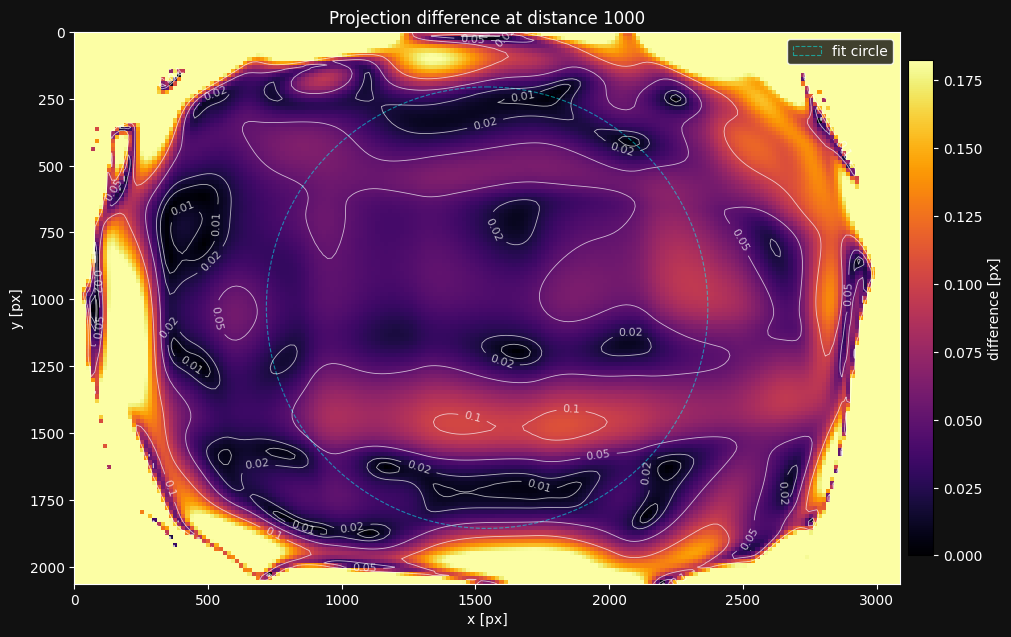

Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1500.9 px
PnP solved 51/51 frames
Running full optimization...
Ran optimizer in 0.31s
Residuals (inliers): mean=0.235px, worst=5.167px
OpenCV seed model ready in 0.8s
Computed FOV from OpenCV model: 141.9° x 124.2°
Calculating matching spline model...
Matching spline model ready in 0.7s
Running full optimization...
Performed full optimization in 2.28s
Outlier filtering: 59/5264 (1.1%) outliers - going again...
Running full optimization...
Performed full optimization in 4.59s
Outlier filtering: 77/5264 (1.5%) outliers - going again...
Running full optimization...
Performed full optimization in 2.41s
Target warp max deflection: 0.4688 (target units)
Residuals (inliers): mean=0.112px, worst=0.513px
Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1677.1 px
PnP solved 50/50 frames
Running full optimization...
Ran optimizer in 0.2

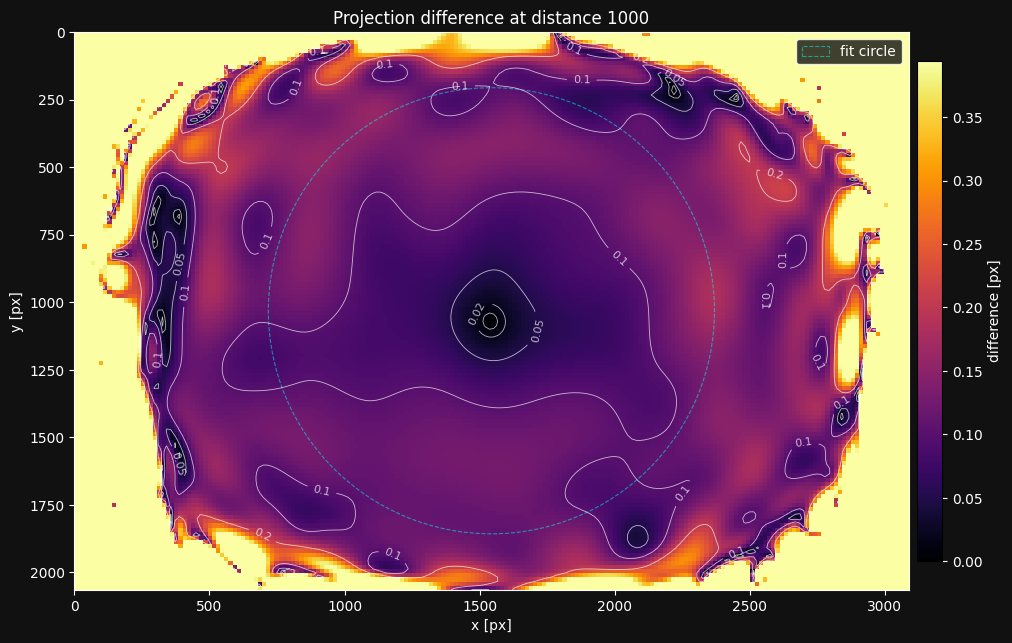

Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1500.9 px
PnP solved 51/51 frames
Running full optimization...
Ran optimizer in 0.33s
Residuals (inliers): mean=0.235px, worst=5.167px
OpenCV seed model ready in 0.8s
Computed FOV from OpenCV model: 141.9° x 124.2°
Calculating matching spline model...
Matching spline model ready in 1.3s
Running full optimization...
Performed full optimization in 6.80s
Outlier filtering: 50/5264 (0.9%) outliers - going again...
Running full optimization...
Performed full optimization in 4.69s
Outlier filtering: 75/5264 (1.4%) outliers - going again...
Running full optimization...
Performed full optimization in 2.41s
Target warp max deflection: 0.4692 (target units)
Residuals (inliers): mean=0.108px, worst=0.543px
Calibrating seed opencv model...
Computing initial poses with PnP...
Auto-estimated initial focal length: 1677.1 px
PnP solved 50/50 frames
Running full optimization...
Ran optimizer in 0.2

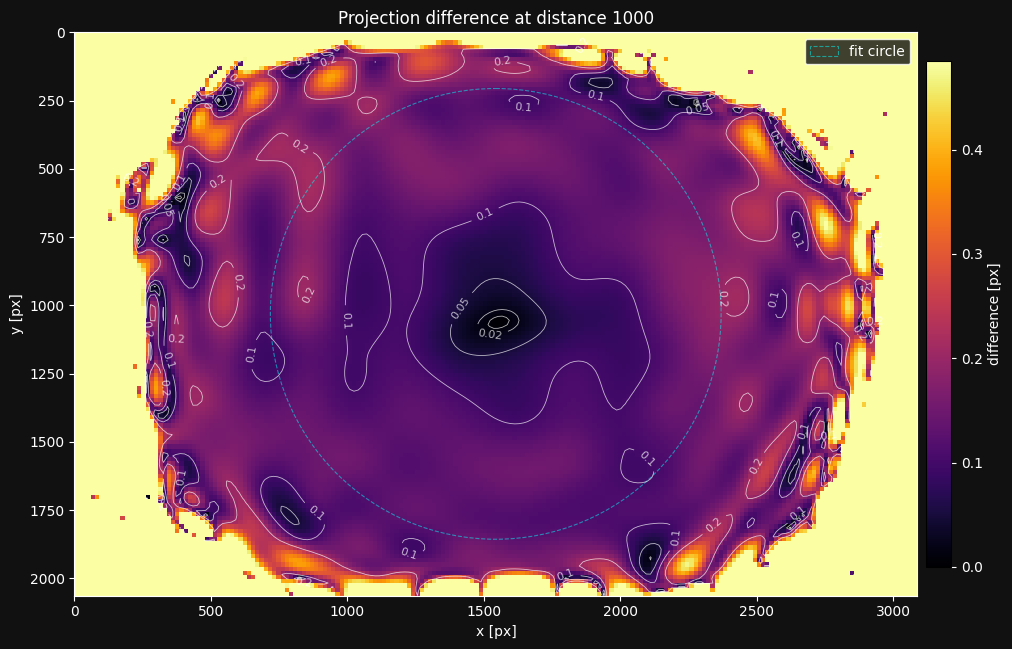

In [10]:
for x_knots in [15, 20, 30, 40]:
    y_knots = int(x_knots * 2/3)

    config = lb.PinholeSplinedConfig(
        image_height=image_height,
        image_width=image_width,
        num_knots_x=x_knots,
        num_knots_y=y_knots,
    )

    result_a = lb.calibrate_camera(
        target_points, 
        frames_a, 
        camera_model_config=config
    )
    result_b = lb.calibrate_camera(
        target_points, 
        frames_b, 
        camera_model_config=config
    )

    spline_model_a = result_a.camera_model
    spline_model_b = result_b.camera_model

    print(f"Result for {x_knots} x {y_knots} grid")

    print(f"Model A sigma: {result_a.residual_sigma_map():.3f} px")
    print(f"Model B sigma: {result_b.residual_sigma_map():.3f} px")

    lba.plot_projection_diff(spline_model_a, spline_model_b, distance=1000)


Interesting! the spine models seem to have higher variance, they differ way more than the opencv models. 
In contrast to the opencv models, it's possible that the reason is that the spline models have way more flexibility in how they overfit and underfit, resulting in higher variance.
We would likely need a larger dataset to reduce the variance.

We can also fit an opencv model and a spline model on all the data and see the difference:

In [11]:
opencv_config = lb.OpenCVConfig(
    image_height=image_height,
    image_width=image_width,
    initial_focal_length=1000,
    included_distortion_coefficients=lb.OpenCVConfig.FULL_14,
)

spline_config = lb.PinholeSplinedConfig(
    image_height=image_height,
    image_width=image_width,
    initial_focal_length=1000,
    num_knots_x=30,
    num_knots_y=20,
)

opencv_result = lb.calibrate_camera(
    target_points, 
    frames, 
    camera_model_config=opencv_config
)
spline_result = lb.calibrate_camera(
    target_points, 
    frames, 
    camera_model_config=spline_config
)

opencv_model = opencv_result.camera_model
spline_model = spline_result.camera_model

Computing initial poses with PnP...
PnP solved 101/101 frames
Running full optimization...
Ran optimizer in 0.61s
Outlier filtering: 90/10424 (0.9%) outliers - going again...
Running full optimization...
Ran optimizer in 0.40s
Outlier filtering: 116/10424 (1.1%) outliers - going again...
Running full optimization...
Ran optimizer in 0.12s
Target warp max deflection: 0.4683 (target units)
Residuals (inliers): mean=0.138px, worst=0.543px
Calibrating seed opencv model...
Computing initial poses with PnP...
PnP solved 101/101 frames
Running full optimization...
Ran optimizer in 0.41s
Residuals (inliers): mean=0.235px, worst=5.170px
OpenCV seed model ready in 0.5s
Computed FOV from OpenCV model: 141.8° x 124.2°
Calculating matching spline model...
Matching spline model ready in 0.8s
Running full optimization...
Performed full optimization in 5.88s
Outlier filtering: 125/10424 (1.2%) outliers - going again...
Running full optimization...
Performed full optimization in 8.99s
Outlier filtering

Implied rotation: x=0.1951 y=-0.1634 z=0.0006 deg
Implied translation: [-2.81522284e-06 -3.36072932e-06  4.25692972e-08]


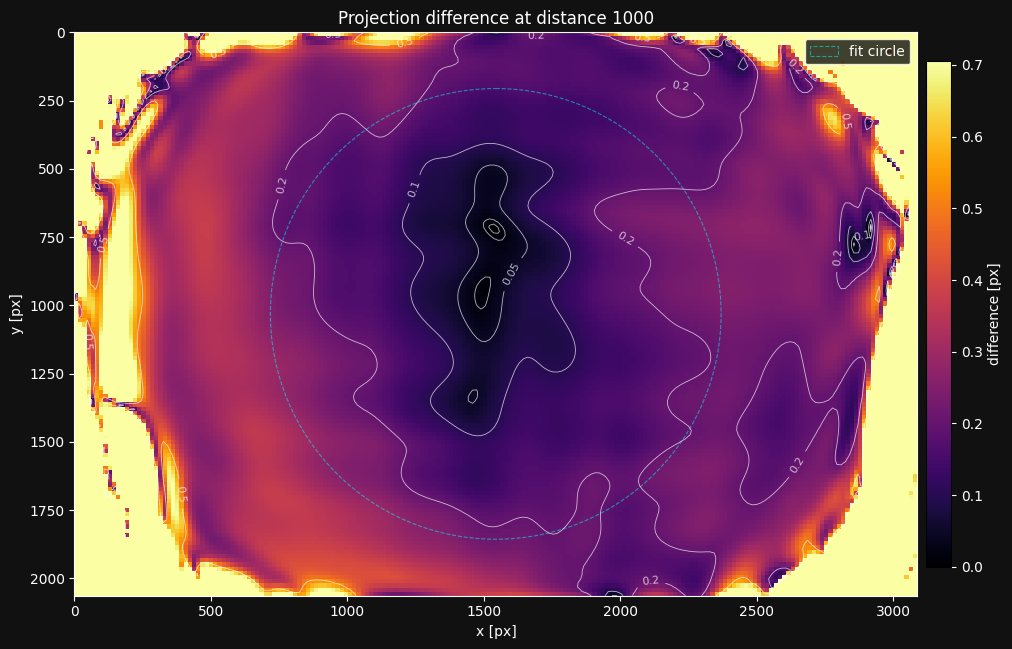

In [12]:
lba.plot_projection_diff(opencv_model, spline_model, distance=1000)

So there you have it, this is how you compare different camera models using `lensboy`.